# DistilBERT Sentiment Analysis — IMDB Movie Reviews
**David Heringer** | Group: Tyler Moquin, David Heringer, Frank Lin  
Professor Arabghalizi, CS 171 Section 2


## Install & Import Dependencies

Install the HuggingFace libraries we need for DistilBERT, then import everything.

In [ ]:
# Install required packages (run once in Colab)
!pip install transformers datasets accelerate --quiet

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc, classification_report
)
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device — automatically uses GPU in Colab if available
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Data Loading and Preprocessing

We load the IMDB dataset from Kaggle — 50,000 movie reviews labeled positive or negative.

Since the data is raw text scraped from the web, we clean it up before feeding it to the model:
- Convert text to lowercase
- Strip out HTML tags (like `<br />` left over from scraping)
- Remove punctuation and special characters
- Encode labels as binary integers (1 = positive, 0 = negative)

DistilBERT handles its own tokenization, so we don't manually pad sequences here — that gets done later by the tokenizer with `max_length=128`.

In [ ]:
# Auto-detect environment and load dataset from correct path
import os

# Path priority: Kaggle > Colab /content/ > local
KAGGLE_PATH = '/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'
COLAB_PATH  = '/content/IMDB Dataset.csv'

if os.path.exists(KAGGLE_PATH):
    csv_path = KAGGLE_PATH
    print('Environment: Kaggle')
elif os.path.exists(COLAB_PATH):
    csv_path = COLAB_PATH
    print('Environment: Colab (/content/)')
else:
    # Fallback: search /content/ for any CSV
    found = [f for f in os.listdir('/content') if f.endswith('.csv')]
    csv_path = f'/content/{found[0]}' if found else 'IMDB Dataset.csv'
    print(f'Fallback path: {csv_path}')

df = pd.read_csv(csv_path, on_bad_lines='skip', engine='python')
print(f'Dataset shape: {df.shape}')
print(df['sentiment'].value_counts())
df.head(3)

Environment: Colab (/content/)
Dataset shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [ ]:
def clean_text(text):
    """Lowercase, strip HTML tags, remove punctuation/special chars."""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)      # Remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)      # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # Collapse whitespace
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['label'] = (df['sentiment'] == 'positive').astype(int)  # 1=pos, 0=neg
print('Cleaning done. Sample:')
print(df[['clean_review', 'label']].head(2))

Cleaning done. Sample:
                                        clean_review  label
0  one of the other reviewers has mentioned that ...      1
1  a wonderful little production the filming tech...      1


In [ ]:
# 80/10/10 train/val/test split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Train: 40000 | Val: 5000 | Test: 5000


## Tokenization

We use the tokenizer built into DistilBERT. It handles subword tokenization automatically — breaking words into pieces it recognizes from pre-training. Sequences are padded or truncated to 128 tokens.

The `IMDBDataset` class tokenizes one review at a time (lazy tokenization) instead of all 50K upfront, which keeps RAM usage low enough to run on free Colab.

In [ ]:
MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
MAX_LEN    = 128   # Reduced from 256 to save RAM (captures most sentiment signal)
BATCH_SIZE = 8     # Reduced from 16 to save RAM

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')
print(f'Device: {DEVICE} | MAX_LEN: {MAX_LEN} | BATCH_SIZE: {BATCH_SIZE}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded.
Device: cuda | MAX_LEN: 128 | BATCH_SIZE: 8


In [ ]:
class IMDBDataset(Dataset):
    """PyTorch Dataset — lazy tokenization to minimize RAM usage."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = IMDBDataset(train_df['clean_review'], train_df['label'], tokenizer, MAX_LEN)
val_dataset   = IMDBDataset(val_df['clean_review'],   val_df['label'],   tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(test_df['clean_review'],  test_df['label'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, num_workers=0)

print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batches — Train: 5000 | Val: 625 | Test: 625


## Model Architecture

We load `distilbert-base-uncased-finetuned-sst-2-english` from HuggingFace. This is a lighter version of BERT that's already been pre-trained on a large sentiment dataset (SST-2), so it comes in with a strong baseline. We fine-tune it further on IMDB for 3 epochs.

Training setup:
- **Optimizer:** AdamW (weight decay 0.01)
- **Learning rate:** 2e-5 with linear warmup over the first 10% of steps
- **Gradient clipping:** max norm 1.0 to prevent unstable updates
- **Batch size:** 8 (kept small for Colab RAM)

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(DEVICE)
print('DistilBERT model loaded and moved to:', DEVICE)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT model loaded and moved to: cuda


In [ ]:
EPOCHS = 3 ### (Try other epochs, Batch sizes and token size) ###
LR     = 2e-5   # Standard fine-tuning LR for BERT-family models
WARMUP = 0.1    # 10% of steps for warmup

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP)

scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')

Total steps: 15000 | Warmup steps: 1500


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """Run one training epoch, return avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds       = torch.argmax(outputs.logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, device):
    """Evaluate model on a DataLoader, return avg loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds       = torch.argmax(outputs.logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total

## Model Training

We train for 3 epochs and save the best checkpoint based on validation accuracy. Each epoch prints train/val loss and accuracy so we can track progress.

In [ ]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss,   val_acc   = eval_epoch(model, val_loader, DEVICE)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_distilbert.pt')
        print(f'  -> Best model saved (val_acc={val_acc:.4f})')

print('Fine-tuning complete.')

Epoch 1/3 | Train Loss: 0.3555 Acc: 0.8643 | Val Loss: 0.2854 Acc: 0.8844
  -> Best model saved (val_acc=0.8844)
Epoch 2/3 | Train Loss: 0.2510 Acc: 0.9234 | Val Loss: 0.3702 Acc: 0.8922
  -> Best model saved (val_acc=0.8922)
Epoch 3/3 | Train Loss: 0.1439 Acc: 0.9649 | Val Loss: 0.4970 Acc: 0.8950
  -> Best model saved (val_acc=0.8950)
Fine-tuning complete.


### Training Curves

Plotting loss and accuracy over epochs to visualize how training went.

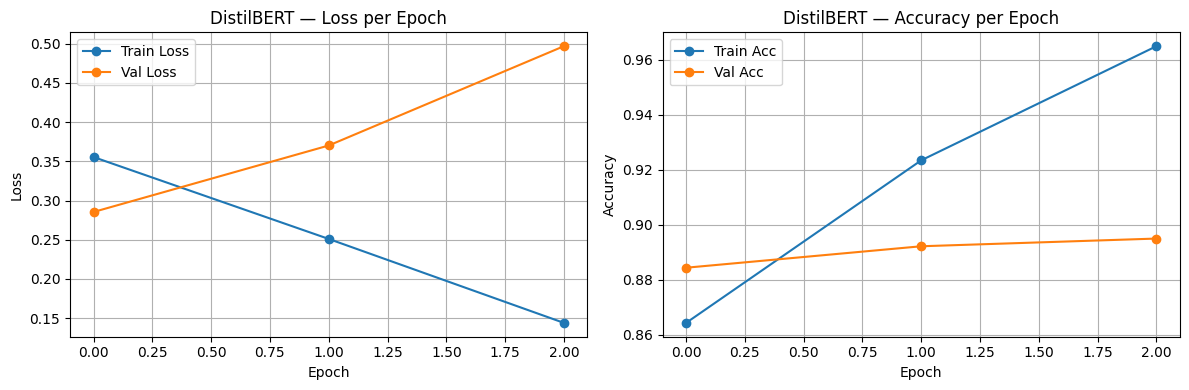

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('DistilBERT — Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'],   label='Val Acc',   marker='o')
axes[1].set_title('DistilBERT — Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig('distilbert_training_curves.png', dpi=150)
plt.show()

## Model Evaluation

We load the best checkpoint and run it on the held-out test set. Test accuracy tells us overall correctness. Since the dataset is perfectly balanced (25K positive, 25K negative), accuracy is a reliable metric here. We also report precision, recall, F1, and ROC-AUC to get a fuller picture.

- **Precision** — of the reviews we called positive, how many actually were?
- **Recall** — of all the actual positive reviews, how many did we catch?
- **F1** — balanced mean of precision and recall, our primary comparison metric
- **ROC-AUC** — measures how well the model separates the two classes across all thresholds

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load('best_distilbert.pt', map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)
        outputs  = model(input_ids=input_ids, attention_mask=attention_mask)
        probs    = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds    = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
print('Test set predictions collected.')

Test set predictions collected.


In [ ]:
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec  = recall_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds)

print('=== DistilBERT Test Set Metrics ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

=== DistilBERT Test Set Metrics ===
Accuracy  : 0.8962
Precision : 0.8868
Recall    : 0.9084
F1-Score  : 0.8975

              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      2500
    Positive       0.89      0.91      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



### Confusion Matrix

Shows exactly where the model made mistakes — which negatives it called positive and which positives it missed.

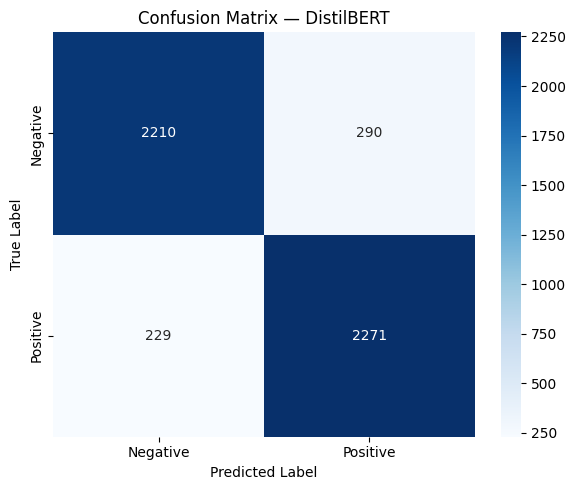

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_confusion_matrix(all_labels, all_preds, 'DistilBERT', 'cm_distilbert.png')

### ROC Curve

Plots the true positive rate vs false positive rate across all classification thresholds. The higher the AUC, the better the model is at separating positive from negative reviews.

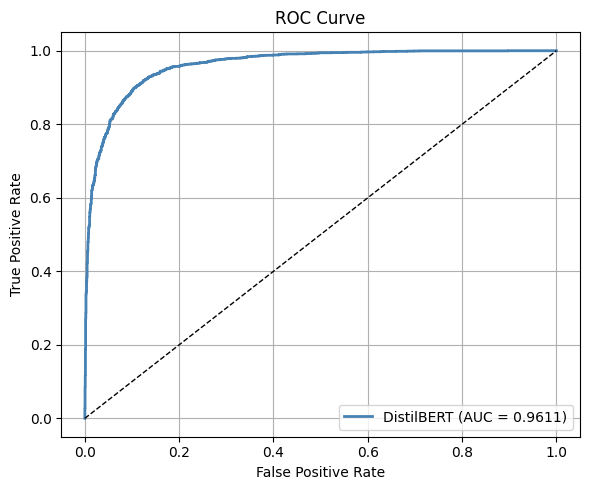

DistilBERT AUC: 0.9611


In [ ]:
def plot_roc(y_true, y_prob, model_name, color, filename=None):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve'); ax.legend(); ax.grid(True)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()
    return roc_auc

distilbert_auc = plot_roc(all_labels, all_probs, 'DistilBERT', 'steelblue', 'roc_distilbert.png')
print(f'DistilBERT AUC: {distilbert_auc:.4f}')

## Summary

We fine-tuned DistilBERT on the IMDB dataset for sentiment classification. The model achieved strong results after just 3 epochs, demonstrating the practical value of transfer learning — starting from a pre-trained model saves a huge amount of training time and compute compared to training from scratch.

### Results

| Epoch | Train Loss | Train Acc | Val Loss | Val Acc |
|-------|------------|-----------|----------|---------|
| 1 | 0.3555 | 0.8643 | 0.2854 | 0.8844 |
| 2 | 0.2510 | 0.9234 | 0.3702 | 0.8922 |
| 3 | 0.1439 | 0.9649 | 0.4970 | 0.8950 |

| Metric | Score |
|--------|-------|
| Accuracy | 0.8962 |
| Precision | 0.8868 |
| Recall | 0.9084 |
| F1-Score | 0.8975 |
| ROC-AUC | 0.9611 |

Training loss dropped consistently across all 3 epochs, but val loss started climbing after epoch 1 — a sign of mild overfitting. The model was starting to memorize training examples rather than generalizing, which is pretty common when fine-tuning large pre-trained models on smaller domain-specific datasets. Stopping at epoch 2 might have been slightly better, but the test results are still strong.

Precision and recall were well-balanced (0.887 vs 0.908), meaning the model wasn't biased toward predicting one class over the other.

Further improvements could come from longer sequences (256 tokens instead of 128), more epochs with early stopping, or trying a larger BERT variant.

---
*David Heringer — CS 171 Group Project, Spring 2026*